# Homework 02: Multi-Class Classification with Neural Networks

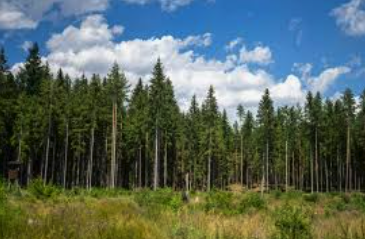

In this assignment, you’ll extend your Keras classification toolkit by training a neural network on a **balanced subset of the Forest Cover (Covertype) dataset**. We’ll begin with a simple baseline network, then study how performance changes as we vary **batch size**, **learning rate**, and apply a **cosine-decay schedule**.

For each configuration, you will consider a range of hyperparameter values, plot training/validation **loss** and **accuracy** over epochs, and determine which choice gave the best performance. 

Finally, you will consider all that you have learned and build your best model and run it on the test set. 


There are 9 graded questions, each worth 9 points, and you get 4 points for free if you complete the whole homework. 


In [1]:
# Useful imports

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_covtype

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import CosineDecay

random_seed = 42

tf.random.set_seed(random_seed)

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # Suppresses INFO and WARNING messages

2026-01-31 22:42:39.323405: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-31 22:42:39.377522: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-31 22:42:41.867863: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


$$k\cdot\sigma$$

In [2]:
# Utility function: Plotting Training Loss (categorical x-entropy) and Accuracy

# Takes the history object returned by fit

def plot_history(history):
    n_epochs = len(history.history['accuracy'])
    epochs = range(1, n_epochs + 1)

    plt.figure(figsize=(7, 8))

    plt.subplot(2, 1, 1)
    plt.plot(epochs, history.history['loss'], label='Training Loss (Xent)', color='tab:red')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.grid(True)
    plt.legend()

    plt.subplot(2, 1, 2)
    plt.plot(epochs, history.history['accuracy'], label='Training Accuracy', color='tab:blue')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1.05)
    plt.title('Training Accuracy')
    plt.grid(True)
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

    final_loss = history.history['loss'][-1]
    final_acc = history.history['accuracy'][-1]
    print(f'Final Training Loss:     {final_loss:.4f}')
    print(f'Final Training Accuracy: {final_acc:.4f}')

## Load the dataset

The dataset is described in detail in the Appendix. For the purposes of this homework, we are selecting a random sample with 2747 samples in each class (to preserve balance), because the original dataset is both very large and very imbalanced, with the smallest class having 2747 samples. 

In [3]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from collections import Counter
import numpy as np

# Load
X, y = fetch_covtype(return_X_y=True)   # y in {1..7}
classes, counts = np.unique(y, return_counts=True)
min_count = counts.min()                # size of rarest class (~2.7k)

# Build perfectly balanced subset (no replacement, no duplicates)
rng = np.random.default_rng(42)
idx_list = []
for c in classes:
    c_idx = np.where(y == c)[0]
    chosen = rng.choice(c_idx, size=min_count, replace=False)
    idx_list.append(chosen)

idx_bal = np.concatenate(idx_list)
rng.shuffle(idx_bal)

X_sub = X[idx_bal]
y_sub = y[idx_bal] - 1                  # relabel to 0..6 for Keras
print("Subset shape:", X_sub.shape, "Class counts:", Counter(y_sub))


Subset shape: (19229, 54) Class counts: Counter({np.int32(3): 2747, np.int32(2): 2747, np.int32(6): 2747, np.int32(5): 2747, np.int32(4): 2747, np.int32(1): 2747, np.int32(0): 2747})


## Problem One: Prepare the dataset and build a baseline model

### Part A: Stratified train/test split and standardization

As in Homework 1, follow these three steps:

1. **Stratified split:**
   Use `train_test_split` with `stratify=y_sub` to preserve class proportions in both training and test sets. Be sure to set `random_state=random_seed` and `test_size=0.2`.

2. **Standardize features:**
   Scale the input features so they have mean 0 and variance 1.



In [4]:
# Your code here
X_train, X_test, y_train, y_test = train_test_split(X_sub, y_sub, 
                                                    test_size=0.2, 
                                                    random_state=random_seed, 
                                                    stratify=y_sub)  # stratify=y ensures that each class is represented in the same proportion in both the training and test sets.
                                                                 # This leads to more reliable results in classification tasks, especially when datasets are small or classes are imbalanced.


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)


print(f'X_train.shape = {X_train.shape}')
print(f'X_test.shape  = {X_test.shape}')
print(f'y_train.shape = {y_train.shape}')
print(f'y_test.shape  = {y_test.shape}')



X_train.shape = (15383, 54)
X_test.shape  = (3846, 54)
y_train.shape = (15383,)
y_test.shape  = (3846,)


### Part B: Build, compile, train, and evaluate the network

1. **Build the model**

   * Use 2 hidden layers:  input &rarr; 64 &rarr; 32 &rarr; output.
   * Apply the `relu` activation for the hidden layers and `softmax` for the output layer.

2. **Compile the model**

    * Use the following parameters


           optimizer = Adam(learning_rate=0.0001),  
           loss = 'sparse_categorical_crossentropy',  
           metrics = ['accuracy']


4. **Train the model**

   * Run for **20 epochs**.
   * Use a `batch_size` of 32.

5. **Evaluate training**

   * Plot the training loss and accuracy curves using `plot_history`.

6. **Answer the graded questions**



In [5]:
# Your code here
#2 hidden layers 

from tensorflow.keras import models, layers

num_features = X_train.shape[1]
print("Number of features:", num_features)

num_classes = len(np.unique(y_train))
print("Number of classes:", num_classes)

model = models.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()


Number of features: 54
Number of classes: 7


2026-01-31 22:42:55.086711: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         3,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,831 (22.78 KB)

 Trainable params: 5,831 (22.78 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
#part 2 

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# part 3

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    verbose=1
)


Epoch 1/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3205 - loss: 1.7774
Epoch 2/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5337 - loss: 1.2672
Epoch 3/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.5964 - loss: 1.0378
Epoch 4/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6231 - loss: 0.9329
Epoch 5/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6440 - loss: 0.8754
Epoch 6/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6572 - loss: 0.8370
Epoch 7/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6698 - loss: 0.8082
Epoch 8/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6830 - loss: 0.7852
Epoch 9/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6917 - loss: 0.7665
Epoch 10/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.6972 - loss: 0.7504
Epoch 11/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7029 - loss: 0.7363
Epoch 12/20
481/481 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

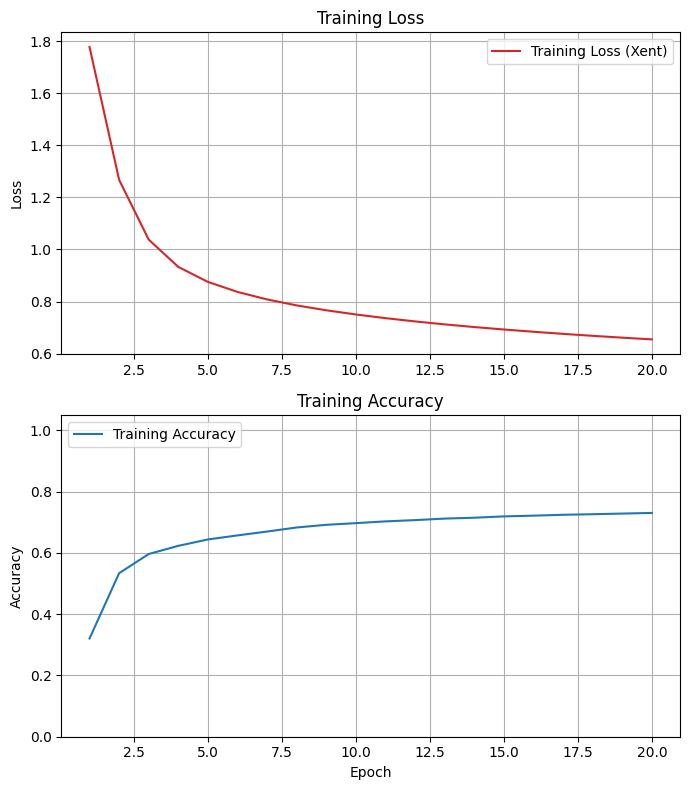

Final Training Loss:     0.6548
Final Training Accuracy: 0.7305


In [8]:
# part 4

plot_history(history)


In [9]:
# Set a1a to the final training accuracy at epoch 20

a1a = history.history['accuracy'][-1]            # Replace 0.0 with your answer

In [10]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a1a = {a1a:.4f}')  

a1a = 0.7305


## Problem Two: Batch Sizes

Next, we’ll explore how the **batch size** affects training. .

* Start with the code from Problem One.
* Run **four experiments** using a batch size of 4, 8, 16, and 128, and  displaying the results using `plot_history`.

* Answer the graded questions.

**Note:** Consider using a `for` loop!


Training with batch_size = 4


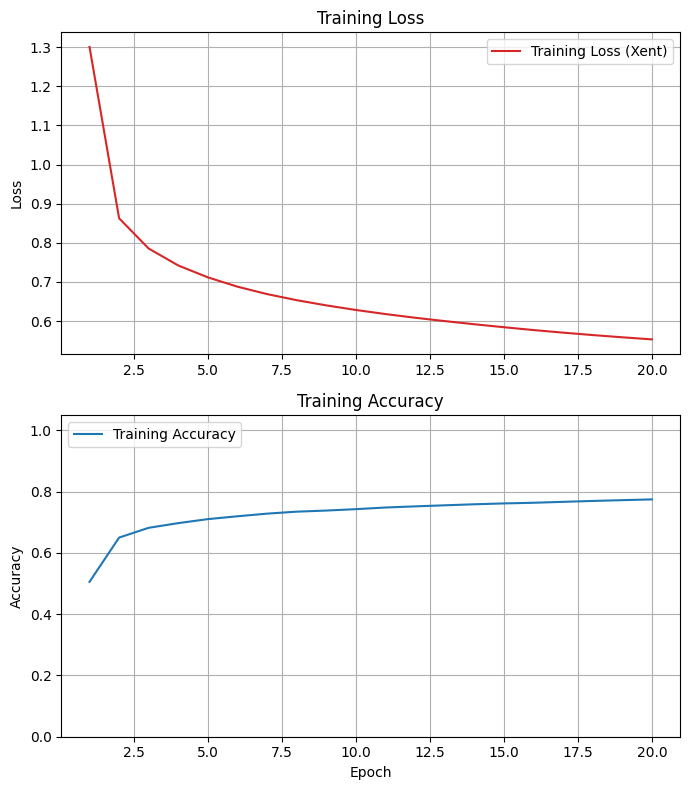

Final Training Loss:     0.5534
Final Training Accuracy: 0.7747
Final Training Accuracy (epoch 20) for batch_size=4: 0.7747

Training with batch_size = 8


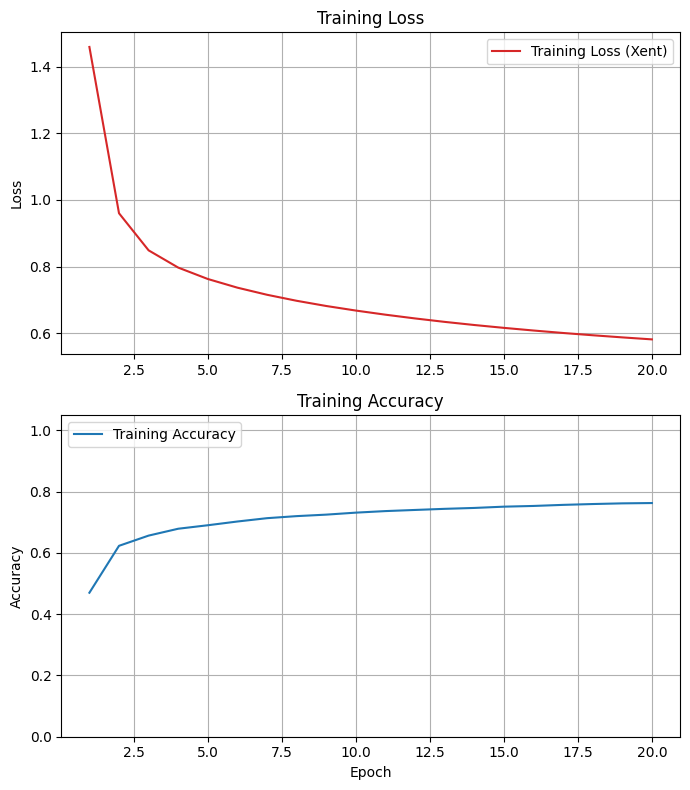

Final Training Loss:     0.5819
Final Training Accuracy: 0.7628
Final Training Accuracy (epoch 20) for batch_size=8: 0.7628

Training with batch_size = 16


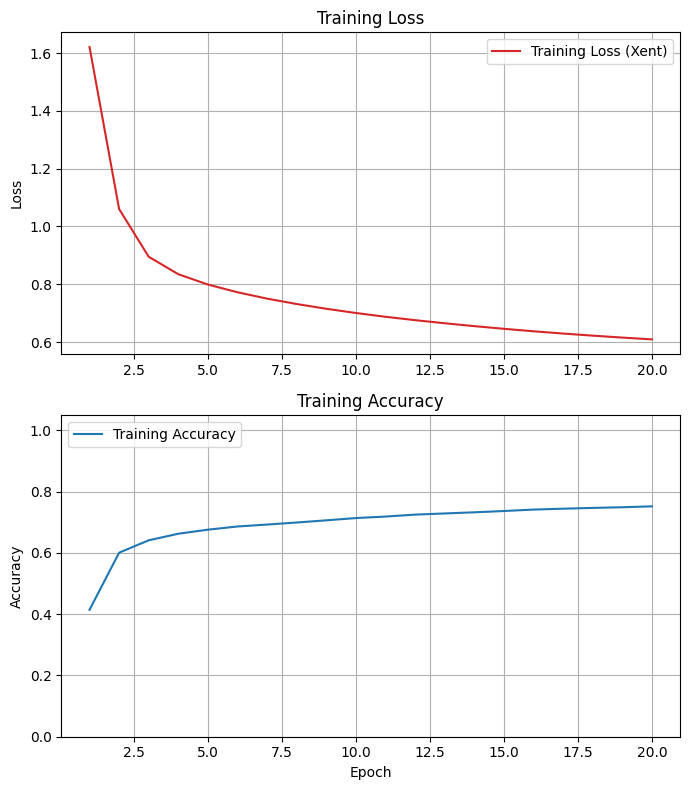

Final Training Loss:     0.6092
Final Training Accuracy: 0.7520
Final Training Accuracy (epoch 20) for batch_size=16: 0.7520

Training with batch_size = 128


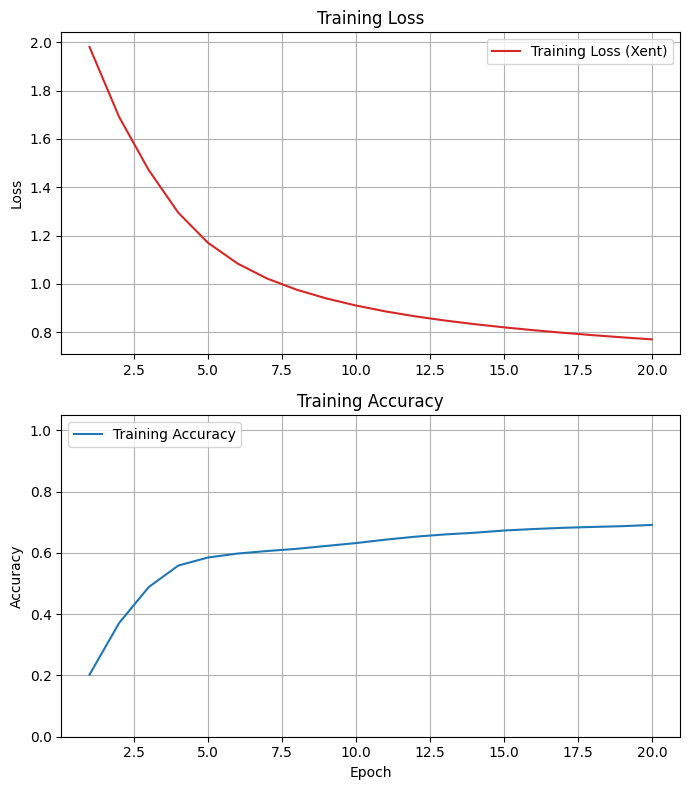

Final Training Loss:     0.7703
Final Training Accuracy: 0.6913
Final Training Accuracy (epoch 20) for batch_size=128: 0.6913


In [11]:
# Your code here
from tensorflow.keras import models, layers


def build_model(num_features, num_classes):
    model = models.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

num_features = X_train.shape[1]
num_classes  = len(np.unique(y_train))

epochs = 20
batch_sizes = [4, 8, 16, 128]

final_acc_by_bs = {}

for bs in batch_sizes:
    print("\n" + "="*60)
    print(f"Training with batch_size = {bs}")

    model = build_model(num_features, num_classes)

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=bs,
        verbose=0
    )

    plot_history(history)

    final_acc = history.history["accuracy"][-1]  
    final_acc_by_bs[bs] = final_acc
    print(f"Final Training Accuracy (epoch {epochs}) for batch_size={bs}: {final_acc:.4f}")


In [12]:
# Set a2a to the batch size which produced the best accuracy score at epoch 20

a2a = max(final_acc_by_bs, key=final_acc_by_bs.get)             # Replace 0 with your answer

In [13]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2a = {a2a}') 

a2a = 4


In [14]:
# Set a2b to the best accuracy score found

a2b = max(final_acc_by_bs.values())         

In [15]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a2b = {a2b:.4f}') 

a2b = 0.7747


## Problem Three: Learning Rates

Next, we’ll explore how the **learning rate** affects training when using the Adam optimizer.

* Start with the code from **Problem One**.
* Add the `learning_rate` parameter to `Adam`.
* Run **five experiments** using the following values:

        [1e-3, 5e-4, 1e-4,5e-5, 1e-5]

* Display your results using `plot_history` and answer the graded questions.



Training with learning_rate = 0.001


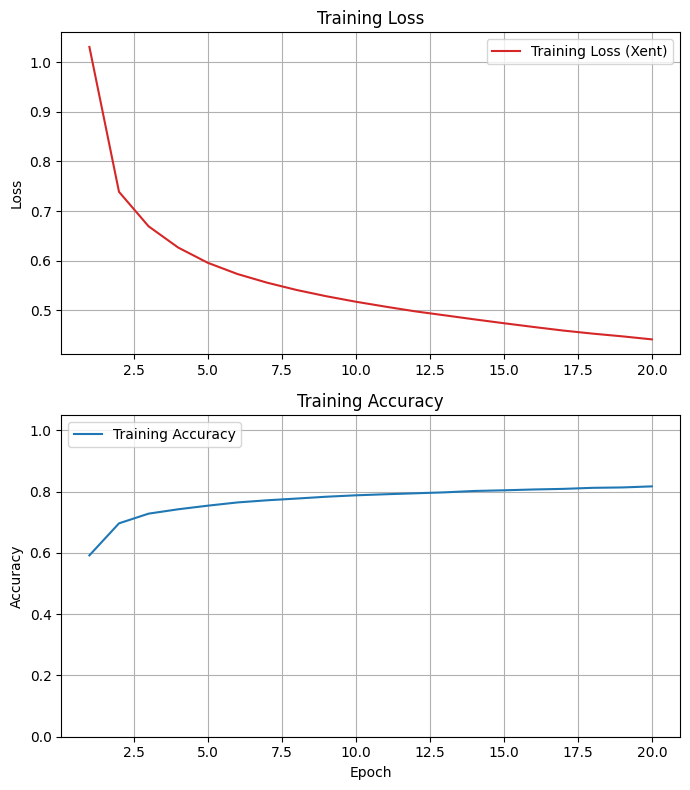

Final Training Loss:     0.4417
Final Training Accuracy: 0.8172
Final Training Accuracy at epoch 20 for lr=0.001: 0.8172

Training with learning_rate = 0.0005


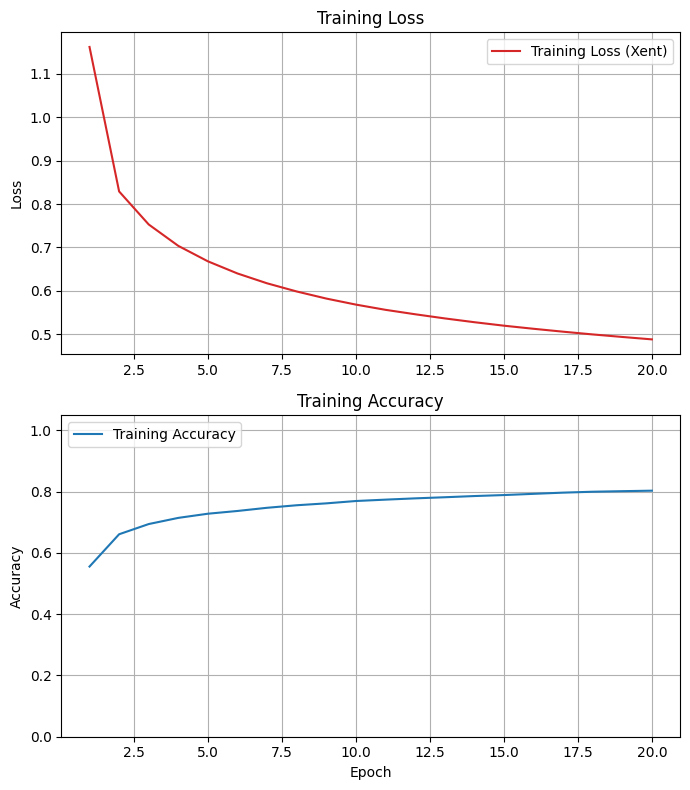

Final Training Loss:     0.4878
Final Training Accuracy: 0.8032
Final Training Accuracy at epoch 20 for lr=0.0005: 0.8032

Training with learning_rate = 0.0001


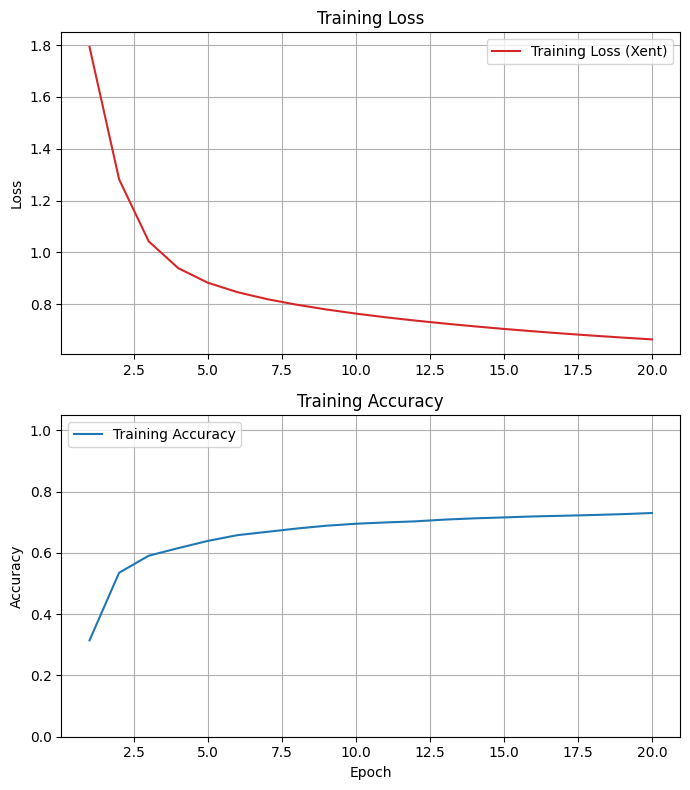

Final Training Loss:     0.6649
Final Training Accuracy: 0.7302
Final Training Accuracy at epoch 20 for lr=0.0001: 0.7302

Training with learning_rate = 5e-05


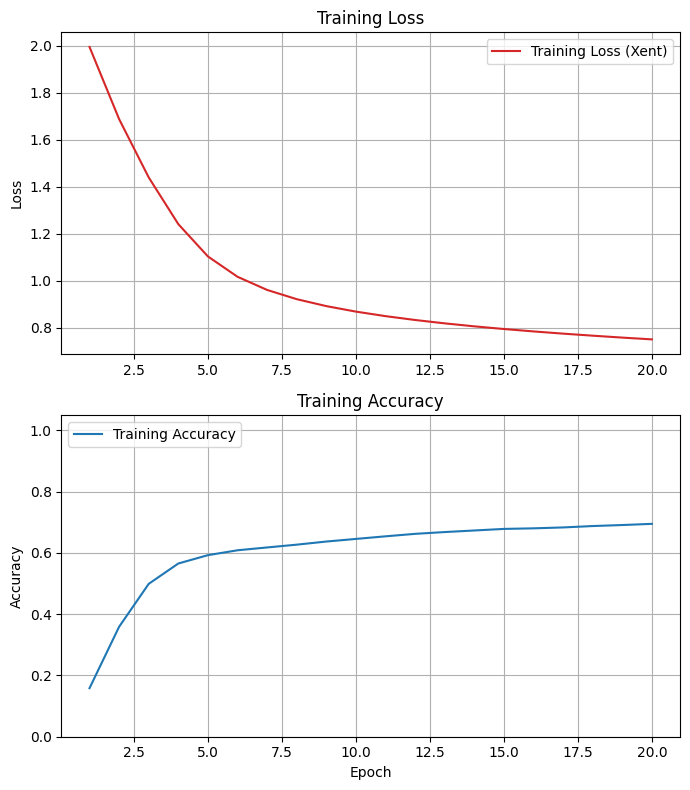

Final Training Loss:     0.7512
Final Training Accuracy: 0.6949
Final Training Accuracy at epoch 20 for lr=5e-05: 0.6949

Training with learning_rate = 1e-05


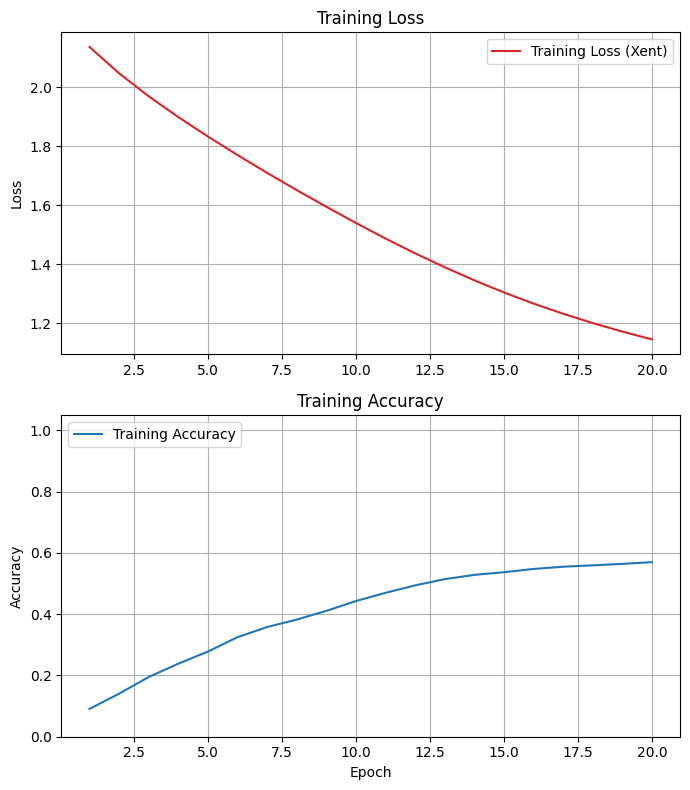

Final Training Loss:     1.1447
Final Training Accuracy: 0.5698
Final Training Accuracy at epoch 20 for lr=1e-05: 0.5698

Final accuracies by learning rate: {0.001: 0.817200779914856, 0.0005: 0.8031593561172485, 0.0001: 0.730221688747406, 5e-05: 0.6948579549789429, 1e-05: 0.5698498487472534}


In [16]:
# Your code here


def build_model(num_features, num_classes, lr):
    model = models.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

num_features = X_train.shape[1]
num_classes  = len(np.unique(y_train))

epochs = 20
learning_rates = [1e-3, 5e-4, 1e-4, 5e-5, 1e-5]

final_acc_by_lr = {}

for lr in learning_rates:
    print("\n" + "="*60)
    print(f"Training with learning_rate = {lr}")

    model = build_model(num_features, num_classes, lr)

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=32,  
        verbose=0
    )

    plot_history(history)

    final_acc = history.history["accuracy"][-1]
    final_acc_by_lr[lr] = final_acc
    print(f"Final Training Accuracy at epoch {epochs} for lr={lr}: {final_acc:.4f}")

print("\nFinal accuracies by learning rate:", final_acc_by_lr)


In [17]:
# Set a3a to the learning rate which produces the best (largest) accuracy at epoch 20

a3a = max(final_acc_by_lr, key=final_acc_by_lr.get)             # Replace 0.0 with your answer

In [18]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3a = {a3a:.4f}') 

a3a = 0.0010


In [19]:
# Set a3b to the accuracy found by the best learning rate

a3b = max(final_acc_by_lr.values())             # Replace 0.0 with your answer

In [20]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a3b = {a3b:.4f}') 

a3b = 0.8172


## Problem Four: Cosine Decay Learning Rate Scheduling

In this problem we'll gain some experience using the Cosine Decay learning rate scheduler with Adam. 

* Start with the code from **Problem One**.
* Define a `CosineDecay` learning rate scheduler (see `Week02_Coding.ipynb` for details)
* Use the scheduler with the Adam optimzier
* Run **five experiments** using the following values for `initial_learning_rate`:

        [1e-2, 5e-3, 1e-3,5e-4, 1e-4]

* Display your results using `plot_history` and answer the graded questions.


Training with CosineDecay initial_learning_rate = 0.01


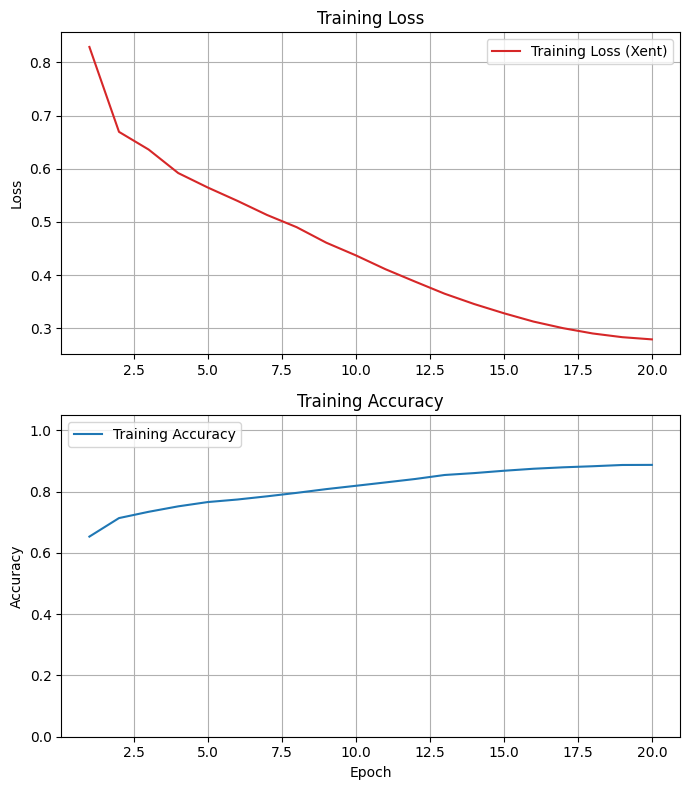

Final Training Loss:     0.2794
Final Training Accuracy: 0.8873
Final Training Accuracy (epoch 20) for init_lr=0.01: 0.8873

Training with CosineDecay initial_learning_rate = 0.005


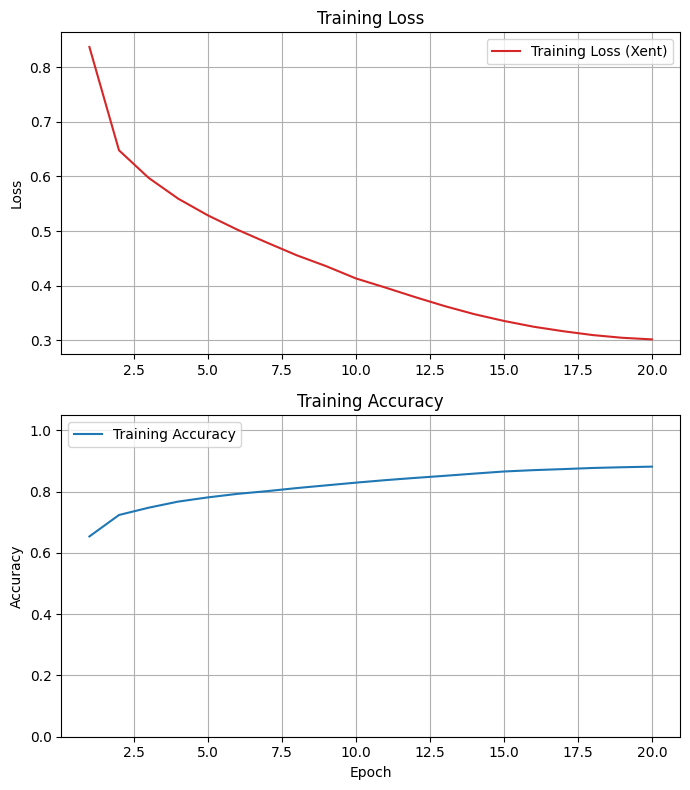

Final Training Loss:     0.3014
Final Training Accuracy: 0.8816
Final Training Accuracy (epoch 20) for init_lr=0.005: 0.8816

Training with CosineDecay initial_learning_rate = 0.001


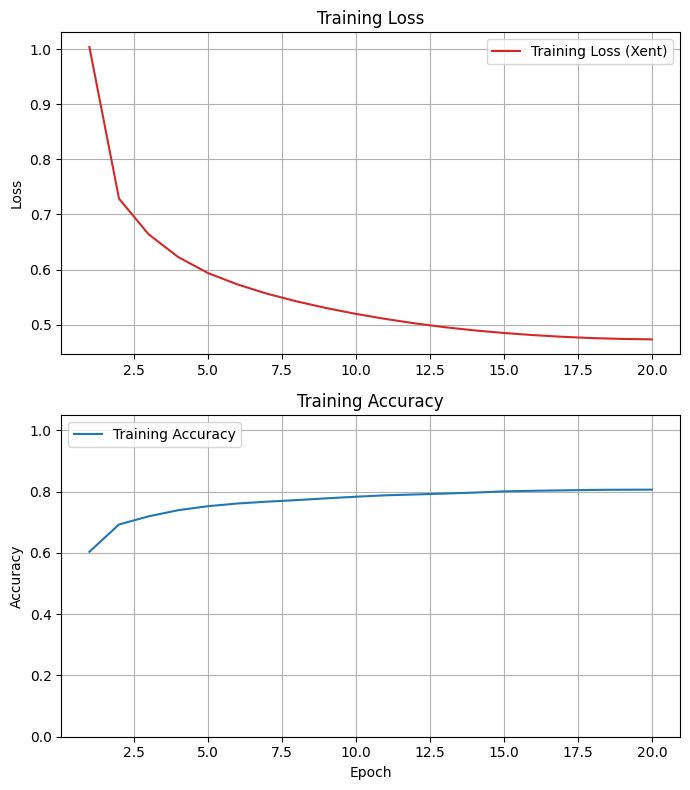

Final Training Loss:     0.4733
Final Training Accuracy: 0.8065
Final Training Accuracy (epoch 20) for init_lr=0.001: 0.8065

Training with CosineDecay initial_learning_rate = 0.0005


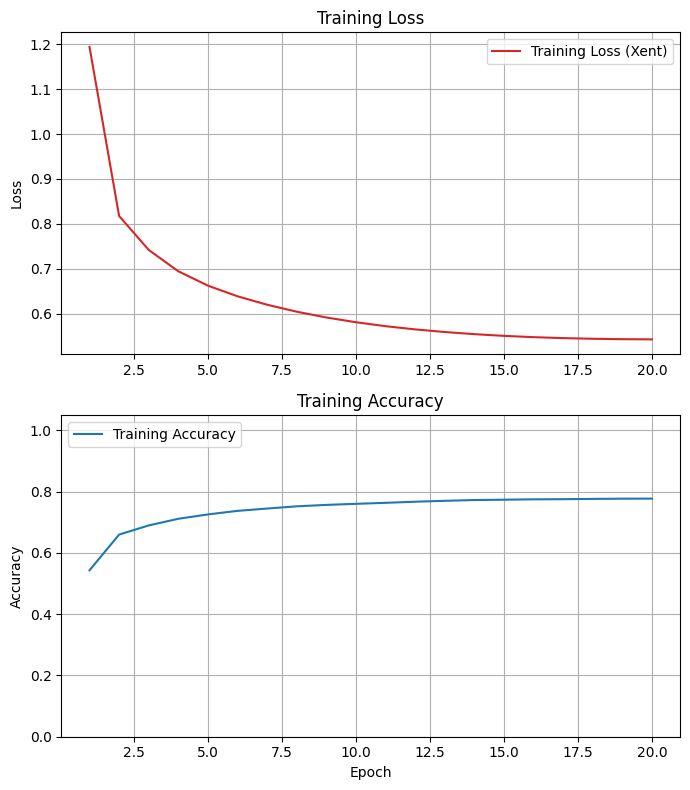

Final Training Loss:     0.5424
Final Training Accuracy: 0.7772
Final Training Accuracy (epoch 20) for init_lr=0.0005: 0.7772

Training with CosineDecay initial_learning_rate = 0.0001


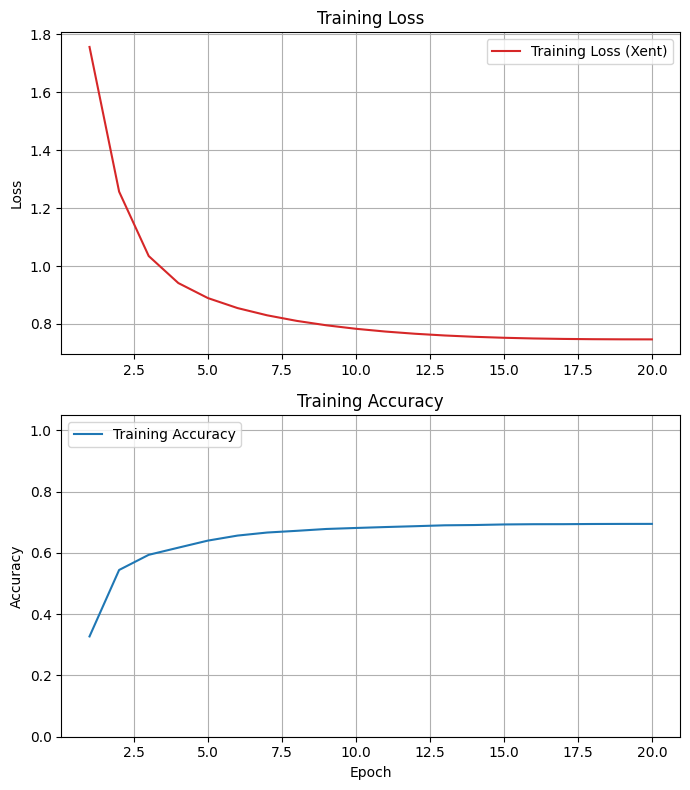

Final Training Loss:     0.7469
Final Training Accuracy: 0.6947
Final Training Accuracy (epoch 20) for init_lr=0.0001: 0.6947

Final accuracies by initial LR: {0.01: 0.887343168258667, 0.005: 0.8816225528717041, 0.001: 0.8065397143363953, 0.0005: 0.7772216200828552, 0.0001: 0.6947279572486877}


In [21]:
# Your code here
from tensorflow.keras.optimizers.schedules import CosineDecay

def build_model(num_features, num_classes):
    model = models.Sequential([
        layers.Input(shape=(num_features,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

num_features = X_train.shape[1]
num_classes  = len(np.unique(y_train))

epochs = 20
batch_size = 32 

# Learning Rate Experiments 
initial_lrs = [1e-2, 5e-3, 1e-3, 5e-4, 1e-4]

final_acc_by_initlr = {}

# steps
steps_per_epoch = int(np.ceil(len(X_train) / batch_size))
total_steps = epochs * steps_per_epoch

for init_lr in initial_lrs:
    print("\n" + "="*60)
    print(f"Training with CosineDecay initial_learning_rate = {init_lr}")

    # Cosine
    lr_schedule = CosineDecay(
        initial_learning_rate=init_lr,
        decay_steps=total_steps,
        alpha=0.0  
    )

    model = build_model(num_features, num_classes)

    model.compile(
        optimizer=Adam(learning_rate=lr_schedule),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        verbose=0
    )

    plot_history(history)

    final_acc = history.history["accuracy"][-1]  # accuracy at epoch 20
    final_acc_by_initlr[init_lr] = final_acc
    print(f"Final Training Accuracy (epoch {epochs}) for init_lr={init_lr}: {final_acc:.4f}")

print("\nFinal accuracies by initial LR:", final_acc_by_initlr)



In [22]:
# Set a4a to the initial learning rate which produced the best accuracy

a4a = max(final_acc_by_initlr, key=final_acc_by_initlr.get)             # Replace 0.0 with your answer

In [23]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4a = {a4a:.4f}') 

a4a = 0.0100


In [24]:
# Set a4b to the best accuracy found

a4b = max(final_acc_by_initlr.values())             # Replace 0.0 with your answer

In [25]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a4b = {a4b:.4f}') 

a4b = 0.8873


## Problem Five: Find the best model and run on the test set

In this final problem, you must consider all the experiments you've done and pick the
set of training hyperparameters which gives you the best accuracy after 20 epochs. Do not change the model architecture. 

Your choices are:

- Which batch size?
- Cosine Decay or constant learning rate?
    - If Cosine Decay, which initial learning rate?
    - If not, which constant learning rate?

* Display your results using `plot_history`
* Run your best model on the test set
* Answer the graded questions.


**OPTIONAL: change the model architecture (but use only dense layers) and try other learning rate schedulers (exponential, step, etc.)**

Epoch 1/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.6252 - loss: 0.8966
Epoch 2/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6643 - loss: 0.8161
Epoch 3/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.6848 - loss: 0.7778
Epoch 4/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7058 - loss: 0.7185
Epoch 5/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7181 - loss: 0.6956
Epoch 6/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7259 - loss: 0.6701
Epoch 7/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7359 - loss: 0.6450
Epoch 8/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7424 - loss: 0.6406
Epoch 9/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7526 - loss: 0.6094
Epoch 10/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7589 - loss: 0.6070
Epoch 11/20
3846/3846 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.7747 - loss: 0.5597
Epoch 12/20
3846/3846 ━━━━━━━━

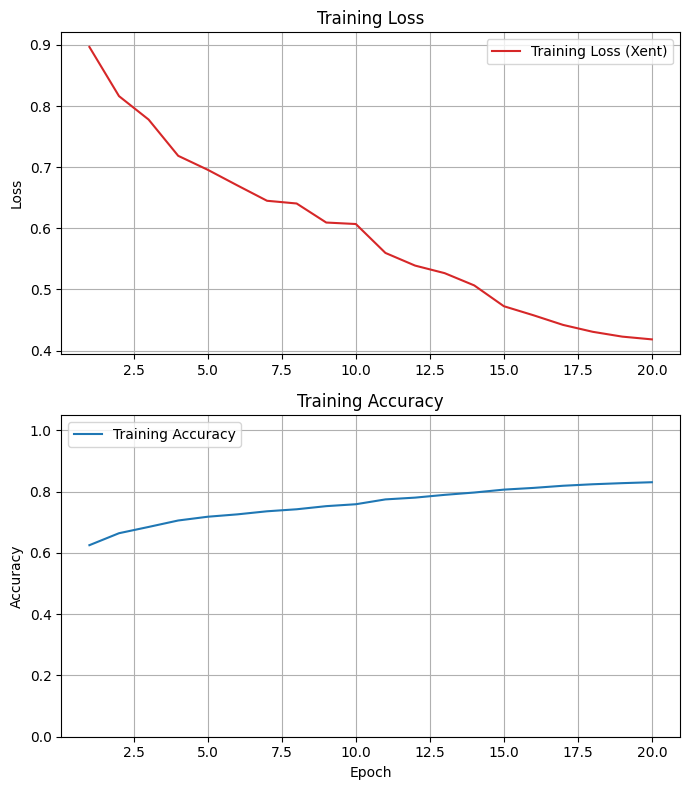

Final Training Loss:     0.4183
Final Training Accuracy: 0.8307
Test Loss: 0.5116
Test Accuracy: 0.8019


In [26]:
# Your code here -- add as many cells as you need

# hyperparams 
best_bs = a2a       
best_init_lr = 1e-2   

epochs = 20

# steps
steps_per_epoch = int(np.ceil(len(X_train) / best_bs))
total_steps = epochs * steps_per_epoch

lr_schedule = CosineDecay(
    initial_learning_rate=best_init_lr,
    decay_steps=total_steps,
    alpha=0.0
)

# model
num_features = X_train.shape[1]
num_classes = len(np.unique(y_train))

best_model = models.Sequential([
    layers.Input(shape=(num_features,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

best_model.compile(
    optimizer=Adam(learning_rate=lr_schedule),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# train
history = best_model.fit(
    X_train, y_train,
    epochs=epochs,
    batch_size=best_bs,
    verbose=1
)

plot_history(history)

# eval
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


In [27]:
# Set a5a to the best training accuracy found by your best model

a5a = history.history["accuracy"][-1]

In [28]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5a = {a5a:.4f}') 

a5a = 0.8307


In [29]:
# Set a5b to the test accuracy found by your best model

a5b = test_acc             # Replace 0.0 with your answer

In [30]:
# Graded Answer
# DO NOT change this cell in any way          

print(f'a5b = {a5b:.4f}') 

a5b = 0.8019


## Reflection Questions (ungraded)

1. We trained on a perfectly balanced \~3.3% subset.
   If we *increase the subset size* (still balanced), how would you expect (a) training time, (b) the best **batch size**, and (c) the best **learning rate** to change? Why?

2. **Batch size trade-offs.**
   With epochs fixed, why do smaller batches often generalize better on tabular data than large batches? What would you change if you *must* use a large batch?

3. **More epochs, same LR.**
    If you doubled the number of epochs (no other changes), what do you think would happen to train loss/acc and test acc? 

4. **Epochs vs. LR.**
   It is natural to think that there is an inverse relationship between the number of epochs and learning rate: if you move more slowly, it will take you longer to reach your goal. Does this seem true given what we have seen in the experiments with learning rate?

# Appendix:  Forest Cover Type (Covertype) — Dataset Overview

This dataset pairs **cartographic features** of 30×30 m land plots with the **dominant tree cover type**. Your task is to predict the cover type from terrain and soil indicators—an archetypal **multi-class classification** problem on tabular data.

**At a glance**

* **Samples:** 581,012 original; we’ll use a **balanced subset** (e.g., 2747 per class) for faster, fairer training.
* **Features (54 total):**

  * **10 continuous:** elevation, aspect, slope, distances to hydrology/roads/fire points, and hillshade at 9 AM/noon/3 PM.
  * **44 binary:** **4 Wilderness\_Area** flags and **40 Soil\_Type** one-hot indicators.
* **Target (7 classes):** Spruce/Fir, Lodgepole Pine, Ponderosa Pine, Cottonwood/Willow, Aspen, Douglas-fir, Krummholz.

**Why it’s useful here**

* Realistic, **tabular** data with mixed feature types.
* Clear demonstration of **scaling** (continuous features) vs. **binary indicators**.
* Originally **imbalanced**, which motivates mindful evaluation (we avoid this by using a balanced subset).


Shape: (19229, 55)

Class distribution:
 Cover_Type
3    0.142857
2    0.142857
6    0.142857
5    0.142857
4    0.142857
1    0.142857
0    0.142857
Name: proportion, dtype: float64


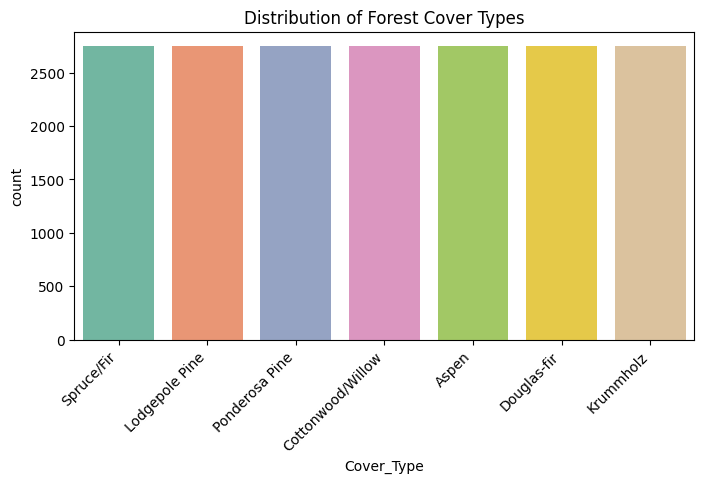

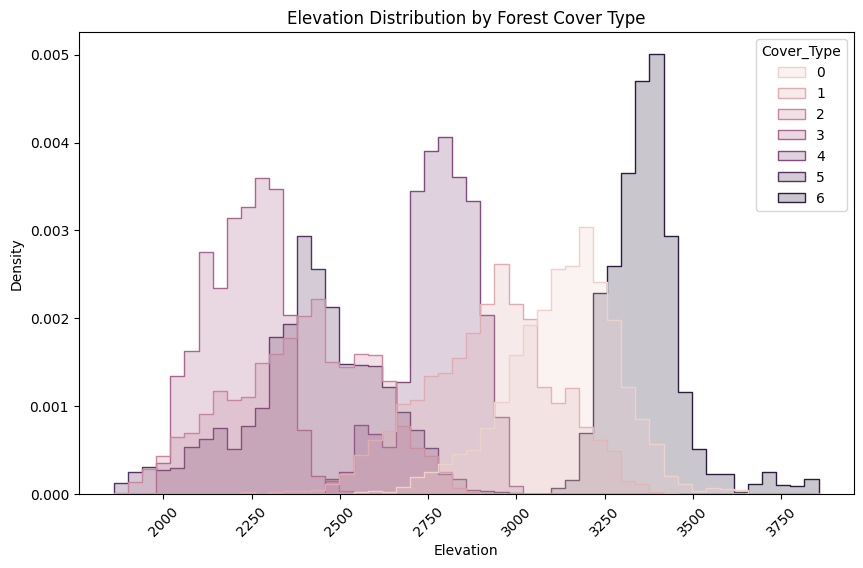

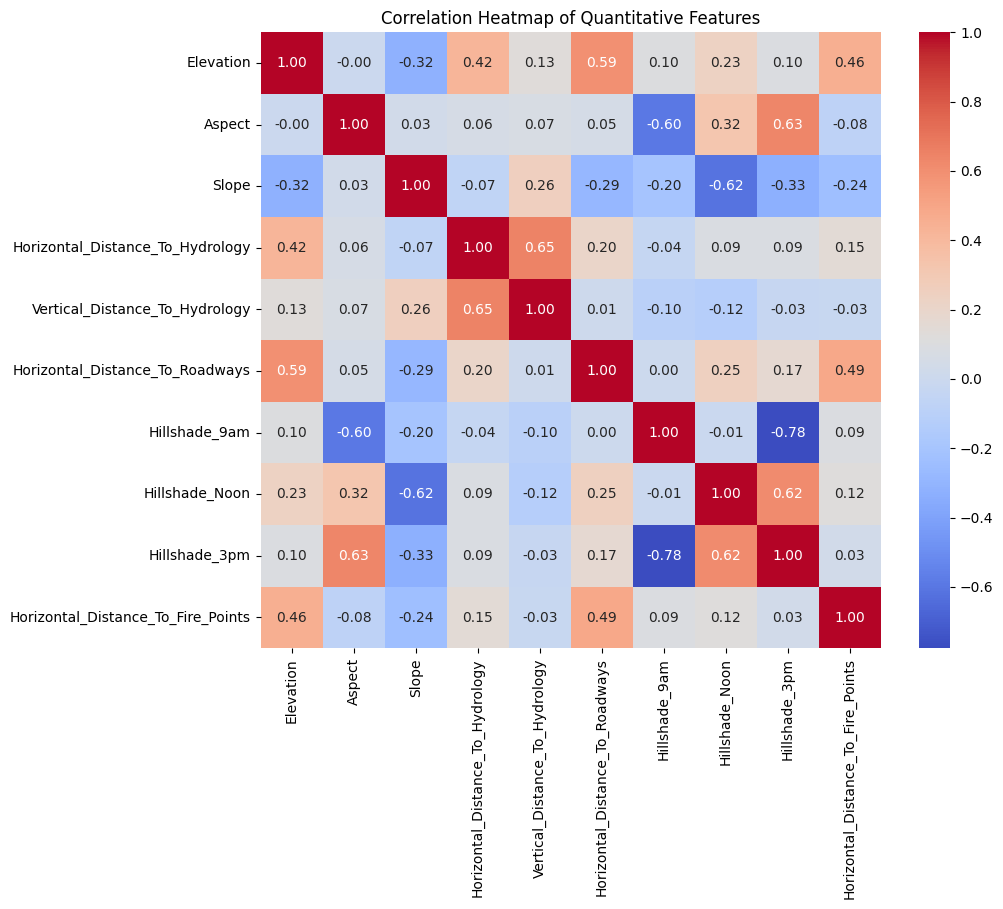

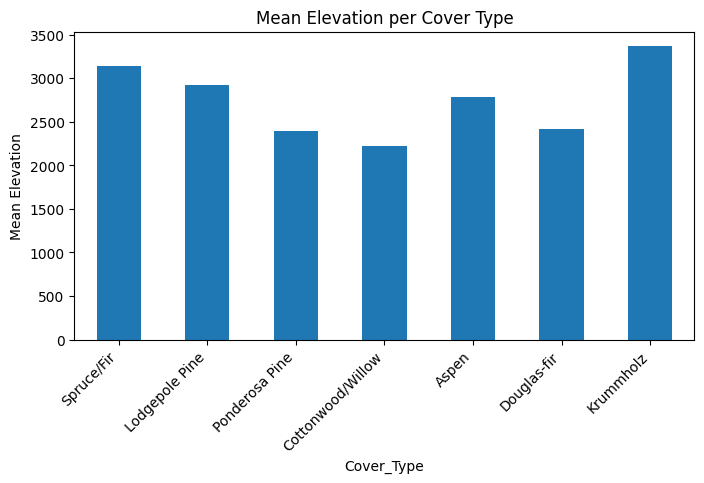

In [31]:
# Attach feature + class names
quant_features = [
    "Elevation", "Aspect", "Slope",
    "Horizontal_Distance_To_Hydrology",
    "Vertical_Distance_To_Hydrology",
    "Horizontal_Distance_To_Roadways",
    "Hillshade_9am", "Hillshade_Noon", "Hillshade_3pm",
    "Horizontal_Distance_To_Fire_Points"
]
wilderness_features = [f"Wilderness_Area{i}" for i in range(1, 5)]
soil_features = [f"Soil_Type{i}" for i in range(1, 41)]

feature_names = quant_features + wilderness_features + soil_features
class_names = [
    "Spruce/Fir", "Lodgepole Pine", "Ponderosa Pine",
    "Cottonwood/Willow", "Aspen", "Douglas-fir", "Krummholz"
]

# Create dataframe from your subset
df = pd.DataFrame(X_sub, columns=feature_names)
df["Cover_Type"] = y_sub

# 1. Basic info
print("Shape:", df.shape)
print("\nClass distribution:\n", df["Cover_Type"].value_counts(normalize=True))

# 2. Class distribution plot
plt.figure(figsize=(8,4))
sns.countplot(x="Cover_Type", hue="Cover_Type", data=df, palette="Set2", legend=False)
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.title("Distribution of Forest Cover Types")
plt.show()

# 3. Elevation distribution by class
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Elevation", hue="Cover_Type",
             bins=50, element="step", stat="density", common_norm=False)
plt.xticks(rotation=45)
plt.title("Elevation Distribution by Forest Cover Type")
plt.show()

# 4. Correlation heatmap (quantitative features only)
plt.figure(figsize=(10,8))
corr = df[quant_features].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Quantitative Features")
plt.show()

# 5. Mean elevation per cover type
df.groupby("Cover_Type")["Elevation"].mean().plot(kind="bar", figsize=(8,4))
plt.xticks(ticks=range(7), labels=class_names, rotation=45, ha="right")
plt.ylabel("Mean Elevation")
plt.title("Mean Elevation per Cover Type")
plt.show()
